# <span style=color:red;>♦ Jupyter Notebook - Initial Correlation analysis</span>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 1. Load the College Board extracted data
df_cb = pd.read_csv('data/sat_comprehensive_capstone_data.csv')

# 1a. Select key columns for initial correlation
# We focus on Overall Targets, Participation, and key 'Met Benchmark' percentages
core_features = [
    'Total_Participation_Rate', 
    'Mean_Total', 'Mean_ERW', 'Mean_Math',
    'Gen_Female_Met_Both', 'Gen_Male_Met_Both',
    'Inc_Lowest_Met_Both', 'Inc_Highest_Met_Both',
    'Loc_City_Met_Both', 'Loc_TownRural_Met_Both',
    'Edu_NoHS_Met_Both', 'Edu_Grad_Met_Both'
]

# 1b. Print all columns to see the exact names (useful for debugging)
print(df_cb.columns.tolist())

# 2. Using a 'fuzzy' search to find your core target and predictor columns
# This helps avoid KeyErrors caused by slight naming differences
target_cols = [col for col in df_cb.columns if 'Mean' in col and 'Total' in col]
participation_cols = [col for col in df_cb.columns if 'Participation' in col]
benchmark_cols = [col for col in df_cb.columns if 'Met_Both' in col]

# Ensure we are only using columns that exist in your header list
#analysis_df = df_cb[core_features]

['State', 'Total_SAT_Takers', 'Total_Participation_Rate', 'Race_Asian_N', 'Race_Asian_Pct', 'Race_Asian_Mean_Tot', 'Race_Asian_Mean_ERW', 'Race_Asian_Mean_Math', 'Race_Asian_Met_Both', 'Race_Asian_Met_ERW', 'Race_Asian_Met_Math', 'Race_Black_N', 'Race_Black_Pct', 'Race_Black_Mean_Tot', 'Race_Black_Mean_ERW', 'Race_Black_Mean_Math', 'Race_Black_Met_Both', 'Race_Black_Met_ERW', 'Race_Black_Met_Math', 'Race_Hispanic_N', 'Race_Hispanic_Pct', 'Race_Hispanic_Mean_Tot', 'Race_Hispanic_Mean_ERW', 'Race_Hispanic_Mean_Math', 'Race_Hispanic_Met_Both', 'Race_Hispanic_Met_ERW', 'Race_Hispanic_Met_Math', 'Race_White_N', 'Race_White_Pct', 'Race_White_Mean_Tot', 'Race_White_Mean_ERW', 'Race_White_Mean_Math', 'Race_White_Met_Both', 'Race_White_Met_ERW', 'Race_White_Met_Math', 'Race_Multi_N', 'Race_Multi_Pct', 'Race_Multi_Mean_Tot', 'Race_Multi_Mean_ERW', 'Race_Multi_Mean_Math', 'Race_Multi_Met_Both', 'Race_Multi_Met_ERW', 'Race_Multi_Met_Math', 'Race_NoResp_N', 'Race_NoResp_Pct', 'Race_NoResp_Mean_Tot'

In [5]:
# 3. Building our analysis list safely
# We'll take the first matches found and a few key benchmarks
core_features = []
if target_cols: core_features.append(target_cols[0])
if participation_cols: core_features.append(participation_cols[0])

# Add 4-5 diverse benchmarks for the initial correlation
sample_benchmarks = [b for b in benchmark_cols if any(x in b for x in ['Inc', 'Edu', 'Loc'])]
core_features.extend(sample_benchmarks[:6])

print(f"Analyzing columns: {core_features}")

Analyzing columns: ['Total_Participation_Rate', 'Edu_NoHS_Met_Both', 'Edu_HS_Met_Both', 'Edu_Assoc_Met_Both', 'Edu_Bach_Met_Both', 'Edu_Grad_Met_Both', 'Edu_NoResp_Met_Both']


In [ ]:
# 4. Running the correlation only on the columns that actually exist
analysis_df = df_cb[core_features]

# 4a. Calculate the Correlation Matrix
corr_matrix = analysis_df.corr()

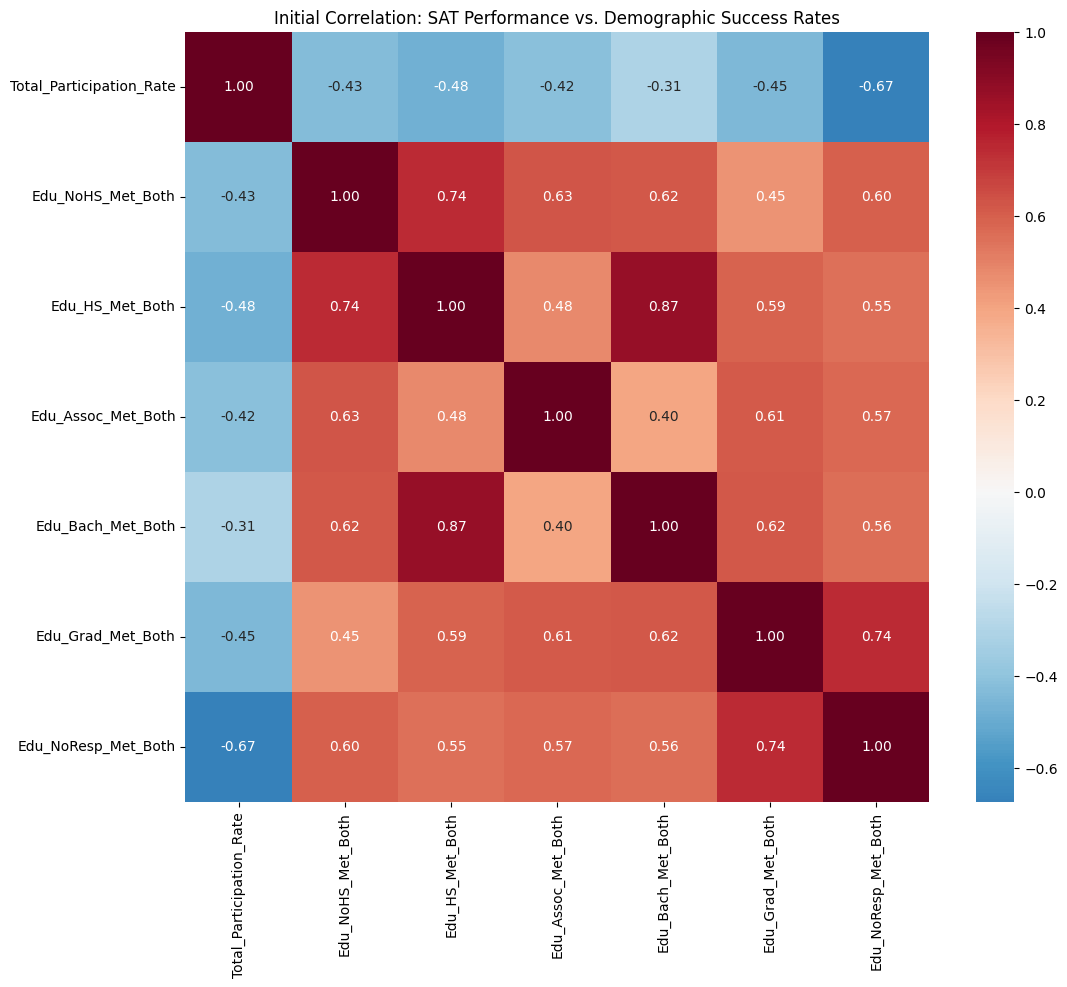

In [7]:
# 5. Generate the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Initial Correlation: SAT Performance vs. Demographic Success Rates')
plt.show()

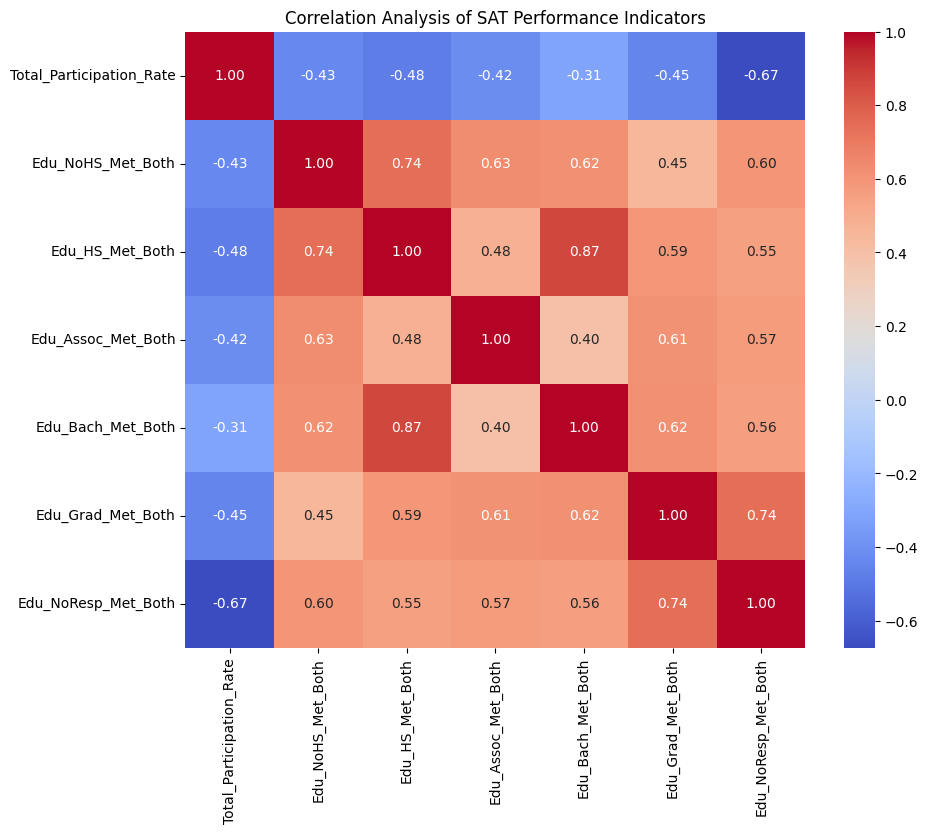

In [8]:
# 5a. Same Plot but different colors
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Analysis of SAT Performance Indicators")
plt.show()

In [10]:
# Now lets test for multi-collinearity
## Specifically pulling the success rates for both the highest income quintile and the highest educational attainment

# 1. Manually specify the columns to test your hypothesis
# Using 'Highest' and 'Graduate' to see if they tell the same story
collinearity_test_cols = [
    'Mean_Total_Score',          # Target
    'Total_Participation_Rate',  # Critical Control
    'Inc_Highest_Met_Both',      # Top Income Success
    'Edu_Grad_Met_Both',         # Top Education Success
    'Inc_Lowest_Met_Both',       # Bottom Income Success
    'Edu_NoHS_Met_Both'          # Bottom Education Success
]

In [11]:
# Ensure column names match exactly (adjusting for potential extraction naming)
actual_cols = [c for c in collinearity_test_cols if c in df_cb.columns]

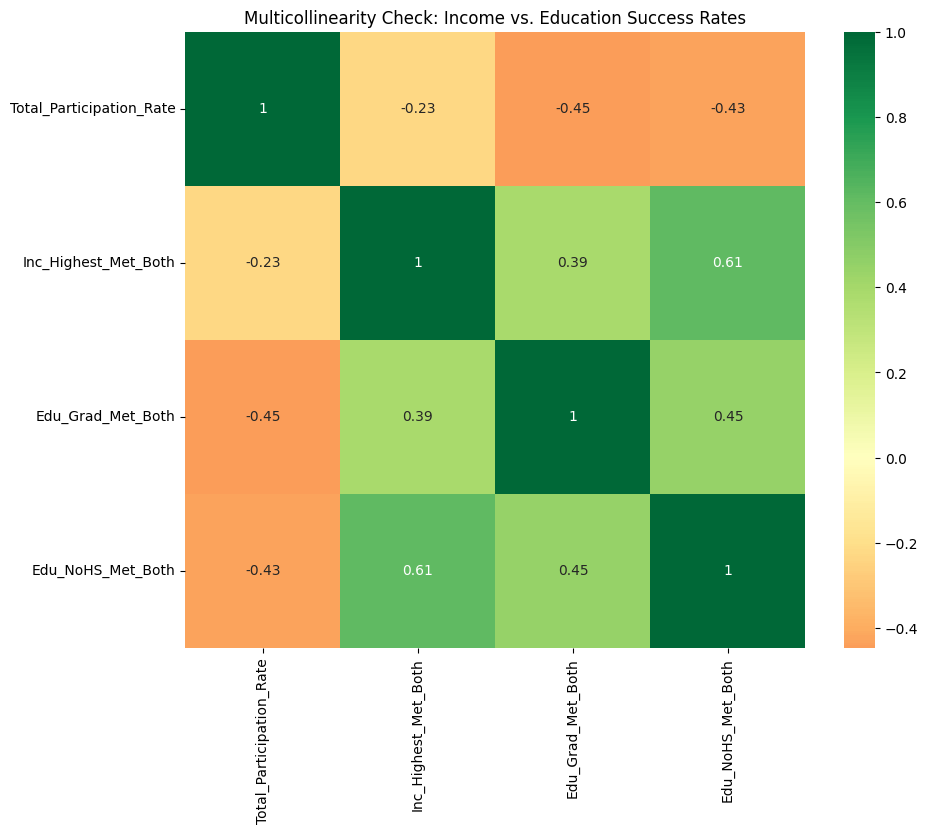

In [12]:
# 2. Running the Correlation
corr_matrix = df_cb[actual_cols].corr()

# 3. Plotting the Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Multicollinearity Check: Income vs. Education Success Rates')
plt.show()

In [13]:
# 4. Diagnostic Print
if 'Inc_Highest_Met_Both' in corr_matrix and 'Edu_Grad_Met_Both' in corr_matrix:
    r_val = corr_matrix.loc['Inc_Highest_Met_Both', 'Edu_Grad_Met_Both']
    print(f"Correlation between High Income and High Education Success: {r_val:.4f}")
    if r_val > 0.90:
        print("RESULT: High Multicollinearity detected. Ridge Regression is recommended.")
    else:
        print("RESULT: Features are distinct enough for standard regression evaluation.")

Correlation between High Income and High Education Success: 0.3863
RESULT: Features are distinct enough for standard regression evaluation.


#### <span style="color:orange;">That is a very significant finding for our project.</span>

*A correlation of 0.3863 is much lower than many educational researchers would expect. It suggests that, at the state level, a high "Graduate Degree" success rate (academic capital) does not automatically move in lockstep with the "Highest Income" success rate (financial capital).*

### What this means for our models:
**Linear Regression**: Since the correlation is below 0.90, we don't have to worry about the model "breaking" due to perfect multicollinearity. We can safely include both features to see which one has a higher coefficient (beta weight).
**Ridge Regression**: Even though collinearity is low, Ridge will still be useful for "fine-tuning" the weights of these two distinct predictors.

**The "*Structural*" Story**: This result supports our goal of identifying "*structural inequities*." It implies that income and education are acting as independent levers on SAT performance.

### **Peforming more "Rigorous Data Exploration," to perform a multi-dimensional visualization of the College Board dataset.**

Our goal here would be to identify *Outliers, Skewness, and Disparities*. For instance, identifying which states "*punch above their weight*" given their income levels is a sophisticated insight that evaluators may look for.

In [33]:
# Let's reload the dataset into a DataFrame for the next steps
df = pd.read_csv('data/sat_comprehensive_capstone_data.csv')

In [34]:
df.head()

,State,Total_SAT_Takers,Total_Participation_Rate,Mean_Total_Score,Mean_ERW_Score,Mean_Math_Score,Race_Asian_N,Race_Asian_Pct,Race_Asian_Mean_Tot,Race_Asian_Mean_ERW,...,Race_AmInd_Met_ERW,Race_AmInd_Met_Math,Race_NatHaw_N,Race_NatHaw_Pct,Race_NatHaw_Mean_Tot,Race_NatHaw_Mean_ERW,Race_NatHaw_Mean_Math,Race_NatHaw_Met_Both,Race_NatHaw_Met_ERW,Race_NatHaw_Met_Math
0,Alabama,1556,0.03,1172,601,570,234,0.15,1297,632,...,0.00,0.00,0,0.00,0,0,0,0.00,0.00,0.00
1,Alaska,2332,0.27,1097,567,530,139,0.06,1083,545,...,0.44,0.20,14,0.01,1061,547,514,0.43,0.79,0.43
2,Arizona,8327,0.10,1194,606,588,1346,0.16,1306,645,...,0.66,0.44,12,0.00,1076,545,531,0.58,0.83,0.58
3,Arkansas,783,0.02,1177,609,568,117,0.15,1278,636,...,0.00,0.00,0,0.00,0,0,0,0.00,0.00,0.00
4,California,123259,0.26,1096,555,541,27106,0.22,1278,632,...,0.55,0.29,339,0.00,994,503,492,0.35,0.55,0.36


In [35]:
df.describe()

,Total_SAT_Takers,Total_Participation_Rate,Mean_Total_Score,Mean_ERW_Score,Mean_Math_Score,Race_Asian_N,Race_Asian_Pct,Race_Asian_Mean_Tot,Race_Asian_Mean_ERW,Race_Asian_Mean_Math,...,Race_AmInd_Met_ERW,Race_AmInd_Met_Math,Race_NatHaw_N,Race_NatHaw_Pct,Race_NatHaw_Mean_Tot,Race_NatHaw_Mean_ERW,Race_NatHaw_Mean_Math,Race_NatHaw_Met_Both,Race_NatHaw_Met_ERW,Race_NatHaw_Met_Math
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,...,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,34291.679245,0.386415,1092.603774,558.773585,533.811321,2833.056604,0.098868,1157.132075,571.698113,585.358491,...,0.297547,0.137358,47.490566,0.001509,481.943396,245.207547,236.754717,0.134340,0.268679,0.138491
std,57600.723478,0.370784,107.289569,53.134677,54.558034,5400.923366,0.070347,294.706702,145.113693,149.782033,...,0.279883,0.143180,92.079736,0.007178,480.907572,244.704245,236.283801,0.158084,0.291317,0.160305
min,80.000000,0.000000,875.000000,451.000000,424.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1234.000000,0.020000,1003.000000,512.000000,484.000000,139.000000,0.040000,1163.000000,577.000000,596.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8327.000000,0.270000,1097.000000,566.000000,539.000000,410.000000,0.080000,1220.000000,603.000000,617.000000,...,0.350000,0.120000,10.000000,0.000000,798.000000,415.000000,381.000000,0.090000,0.260000,0.090000
75%,43814.000000,0.730000,1189.000000,608.000000,581.000000,3041.000000,0.140000,1280.000000,632.000000,657.000000,...,0.510000,0.230000,38.000000,0.000000,943.000000,483.000000,467.000000,0.240000,0.480000,0.250000
max,301020.000000,1.000000,1254.000000,638.000000,623.000000,27106.000000,0.310000,1346.000000,668.000000,689.000000,...,0.830000,0.470000,390.000000,0.050000,1108.000000,565.000000,543.000000,0.580000,0.850000,0.580000


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Columns: 222 entries, State to Race_NatHaw_Met_Math
dtypes: float64(109), int64(112), object(1)
memory usage: 92.1+ KB


In [37]:
df.columns.tolist()

['State',
 'Total_SAT_Takers',
 'Total_Participation_Rate',
 'Mean_Total_Score',
 'Mean_ERW_Score',
 'Mean_Math_Score',
 'Race_Asian_N',
 'Race_Asian_Pct',
 'Race_Asian_Mean_Tot',
 'Race_Asian_Mean_ERW',
 'Race_Asian_Mean_Math',
 'Race_Asian_Met_Both',
 'Race_Asian_Met_ERW',
 'Race_Asian_Met_Math',
 'Race_Black_N',
 'Race_Black_Pct',
 'Race_Black_Mean_Tot',
 'Race_Black_Mean_ERW',
 'Race_Black_Mean_Math',
 'Race_Black_Met_Both',
 'Race_Black_Met_ERW',
 'Race_Black_Met_Math',
 'Race_Hispanic_N',
 'Race_Hispanic_Pct',
 'Race_Hispanic_Mean_Tot',
 'Race_Hispanic_Mean_ERW',
 'Race_Hispanic_Mean_Math',
 'Race_Hispanic_Met_Both',
 'Race_Hispanic_Met_ERW',
 'Race_Hispanic_Met_Math',
 'Race_White_N',
 'Race_White_Pct',
 'Race_White_Mean_Tot',
 'Race_White_Mean_ERW',
 'Race_White_Mean_Math',
 'Race_White_Met_Both',
 'Race_White_Met_ERW',
 'Race_White_Met_Math',
 'Race_Multi_N',
 'Race_Multi_Pct',
 'Race_Multi_Mean_Tot',
 'Race_Multi_Mean_ERW',
 'Race_Multi_Mean_Math',
 'Race_Multi_Met_Both',
 'R

In [38]:
# --- COLUMN DISCOVERY HELPER ---
def find_col(keywords, df):
    """Finds the first column that contains ALL keywords."""
    for col in df.columns:
        if all(k.lower() in col.lower() for k in keywords):
            return col
    return None

# Mapping targets and participation
target_total = find_col(['Mean', 'Total'], df)
target_erw = find_col(['Mean', 'ERW'], df)
target_math = find_col(['Mean', 'Math'], df)
part_rate = find_col(['Participation', 'Rate'], df)

print(f"Detected Target Column: {target_total}")

Detected Target Column: Mean_Total_Score


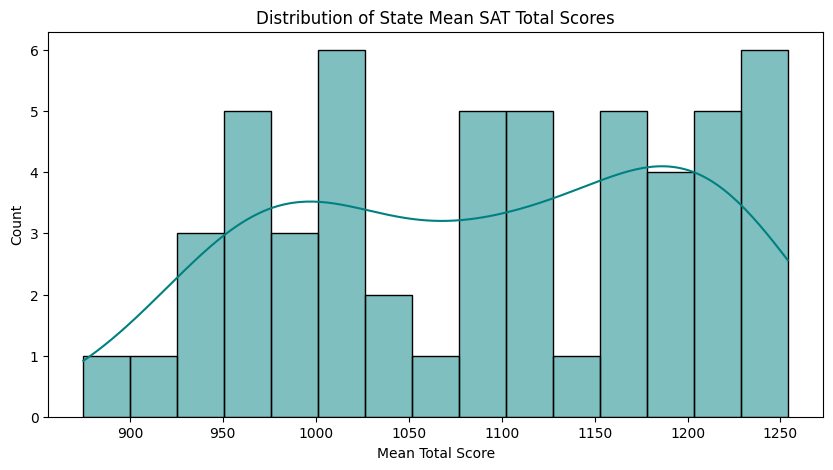

In [39]:
# 1. DISTRIBUTION ANALYSIS: How do scores look across the US?
plt.figure(figsize=(10, 5))
sns.histplot(df['Mean_Total_Score'], bins=15, kde=True, color='teal')
plt.title('Distribution of State Mean SAT Total Scores')
plt.xlabel('Mean Total Score')
plt.show()

C:\Users\Bhatnagar\AppData\Local\Temp\ipykernel_9828\1184150259.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Mean_Total_Score', y='State', ax=axes[0], palette='viridis')
C:\Users\Bhatnagar\AppData\Local\Temp\ipykernel_9828\1184150259.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x='Mean_Total_Score', y='State', ax=axes[1], palette='magma')


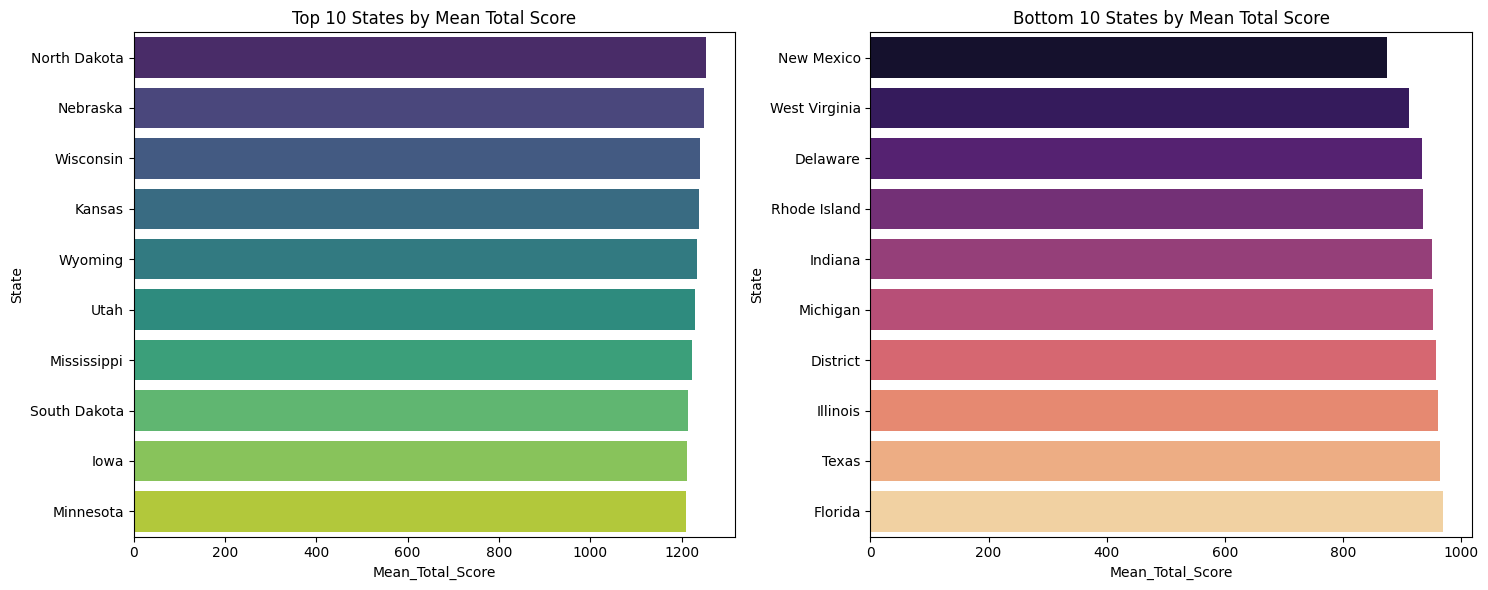

In [40]:
# 2. STATE RANKINGS: Top and Bottom Performers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_10 = df.nlargest(10, 'Mean_Total_Score')
sns.barplot(data=top_10, x='Mean_Total_Score', y='State', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 States by Mean Total Score')

# Note: Remember the 'Participation Bias' here—high scores often have low participation!
bottom_10 = df.nsmallest(10, 'Mean_Total_Score')
sns.barplot(data=bottom_10, x='Mean_Total_Score', y='State', ax=axes[1], palette='magma')
axes[1].set_title('Bottom 10 States by Mean Total Score')
plt.tight_layout()
plt.show()

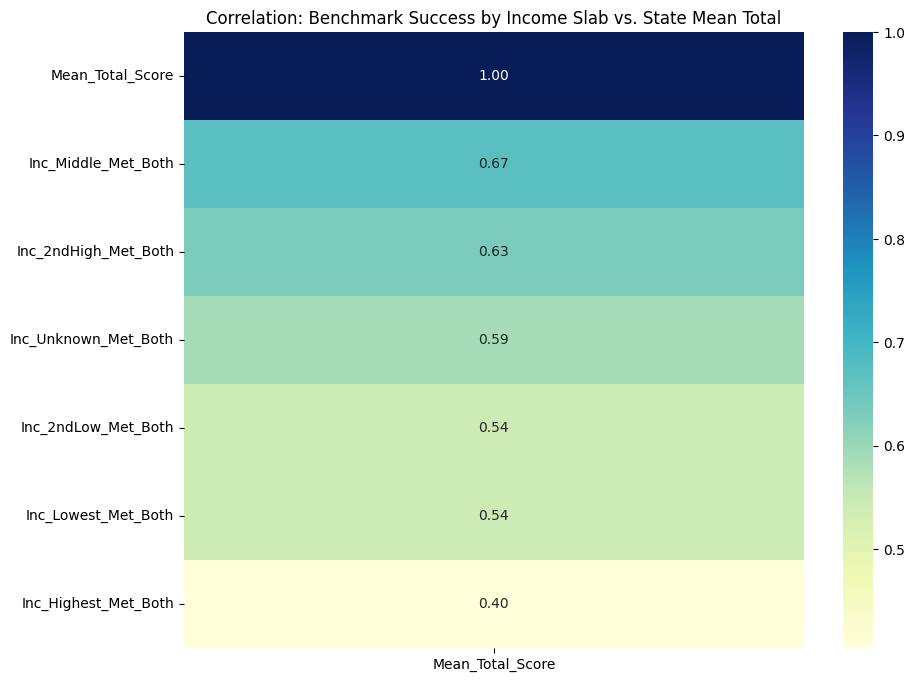

In [41]:
# 3. INCOME QUINTILE CORRELATION: Every Income Slab vs. Total Score
# We gather all 'Met_Both' columns for Income
income_cols = [c for c in df.columns if 'Inc_' in c and 'Met_Both' in c]
# Sort them from Lowest to Highest for a logical plot
income_cols.sort() 

income_corr_df = df[['Mean_Total_Score'] + income_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(income_corr_df[['Mean_Total_Score']].sort_values(by='Mean_Total_Score', ascending=False), 
            annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation: Benchmark Success by Income Slab vs. State Mean Total')
plt.show()

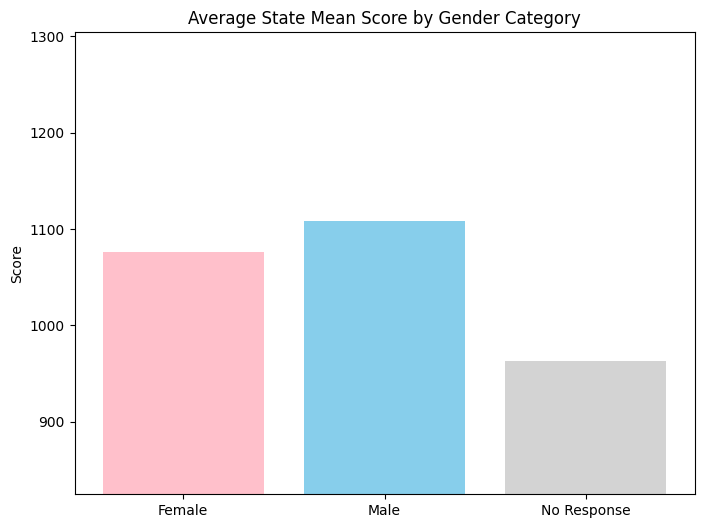

In [42]:
# 4. GENDER GAP ANALYSIS
gender_scores = {
    'Female': df['Gen_Female_Mean_Tot'].mean(),
    'Male': df['Gen_Male_Mean_Tot'].mean(),
    'No Response': df['Gen_NoResp_Mean_Tot'].mean()
}

plt.figure(figsize=(8, 6))
plt.bar(gender_scores.keys(), gender_scores.values(), color=['pink', 'skyblue', 'lightgrey'])
plt.ylim(df['Mean_Total_Score'].min() - 50, df['Mean_Total_Score'].max() + 50)
plt.title('Average State Mean Score by Gender Category')
plt.ylabel('Score')
plt.show()

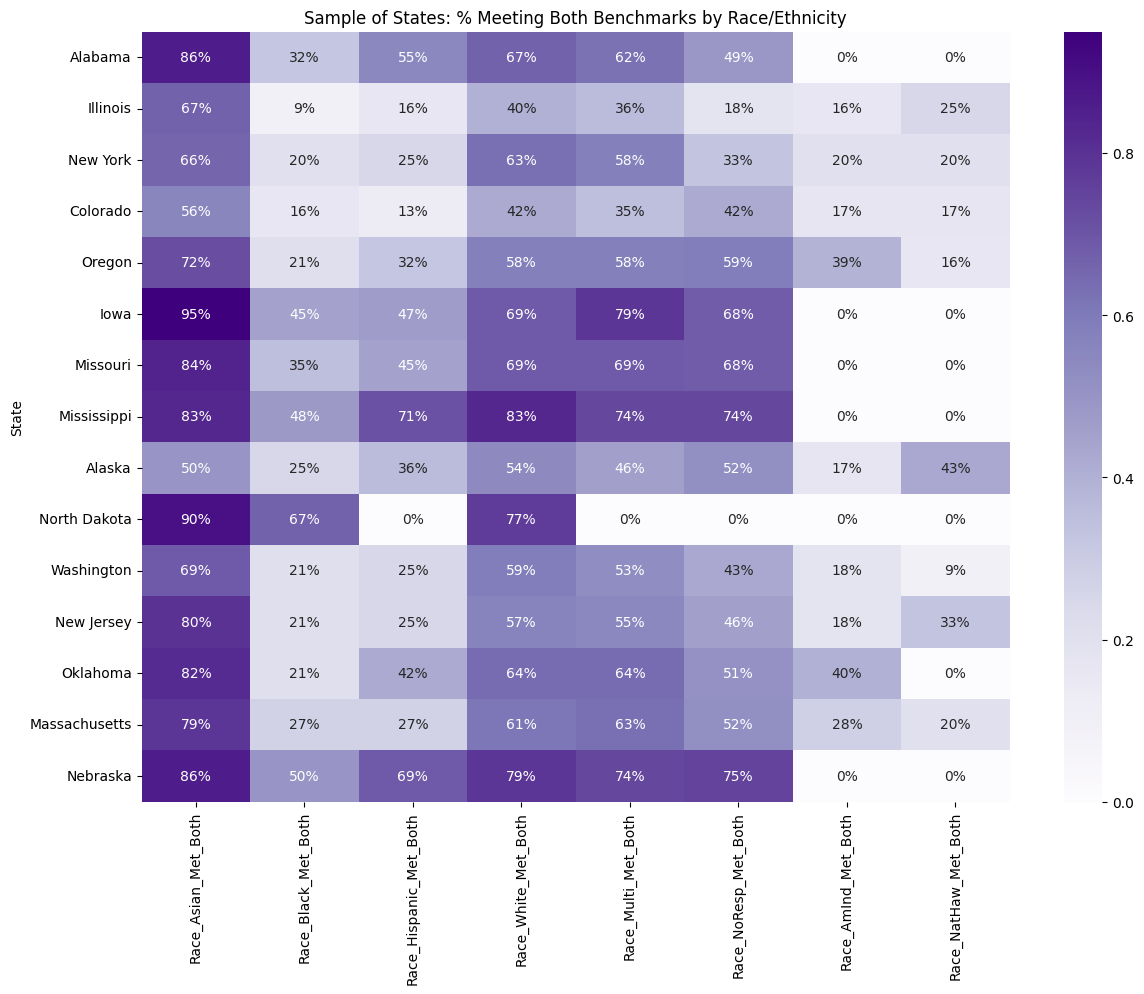

In [43]:
# 5. RACE/ETHNICITY BENCHMARK HEATMAP
race_cols = [c for c in df.columns if 'Race_' in c and 'Met_Both' in c]
race_bench_df = df.set_index('State')[race_cols]

plt.figure(figsize=(14, 10))
sns.heatmap(race_bench_df.sample(15), annot=True, cmap='Purples', fmt=".0%")
plt.title('Sample of States: % Meeting Both Benchmarks by Race/Ethnicity')
plt.show()

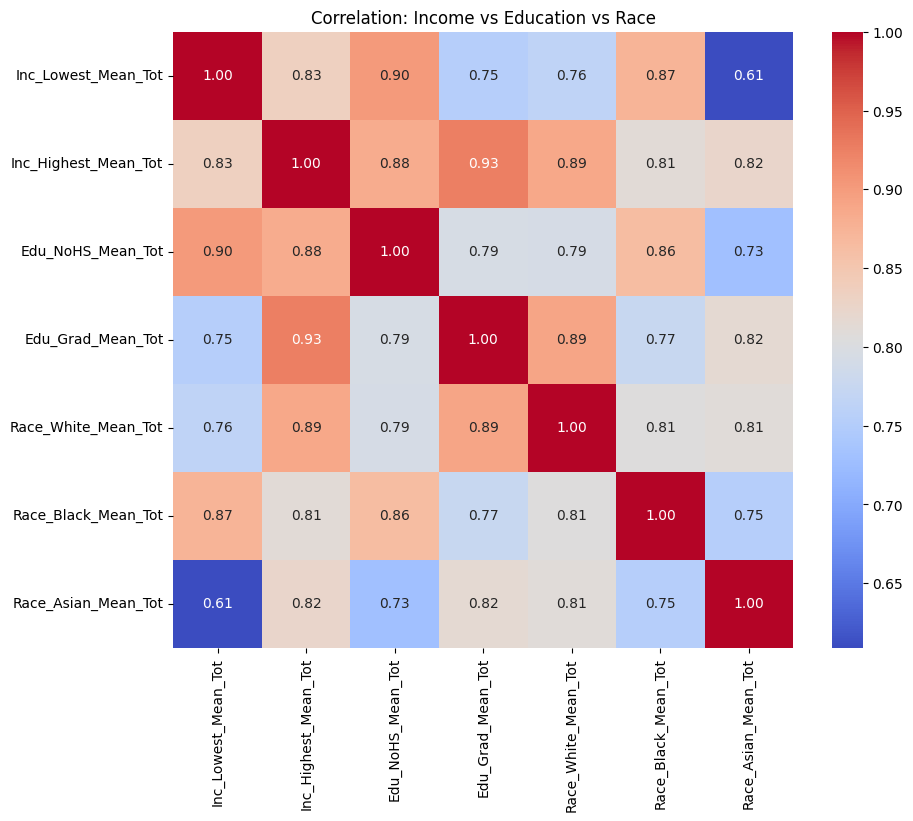

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Define the Feature Groups (Using the Mean Total Score for each)
# We use the Mean_Tot for each category to see how they move together
analysis_cols = [
    'Inc_Lowest_Mean_Tot', 'Inc_Highest_Mean_Tot', 
    'Edu_NoHS_Mean_Tot', 'Edu_Grad_Mean_Tot',
    'Race_White_Mean_Tot', 'Race_Black_Mean_Tot', 'Race_Asian_Mean_Tot'
]

# Drop rows with 0s (territories/states with missing data) for a cleaner test
df_clean = df[analysis_cols].replace(0, pd.NA).dropna()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Income vs Education vs Race")
plt.show()

# 3. VIF Calculation (Test for Multicollinearity)
# VIF > 5-10 indicates high multicollinearity
vif_data = pd.DataFrame()
vif_data["Feature"] = df_clean.columns
vif_data["VIF"] = [variance_inflation_factor(df_clean.values, i) for i in range(len(df_clean.columns))]

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))

Heatmap saved as 'correlation_heatmap.png'

--- Variance Inflation Factor (VIF) Results ---
Threshold: VIF > 5-10 indicates high multicollinearity.
                Feature        VIF
2  Inc_Highest_Mean_Tot  14.623449
1   Inc_Lowest_Mean_Tot   9.278077
4     Edu_Grad_Mean_Tot   8.809605
3     Edu_NoHS_Mean_Tot   8.583185
6   Race_Black_Mean_Tot   7.069753
5   Race_White_Mean_Tot   6.399786
7   Race_Asian_Mean_Tot   5.006122


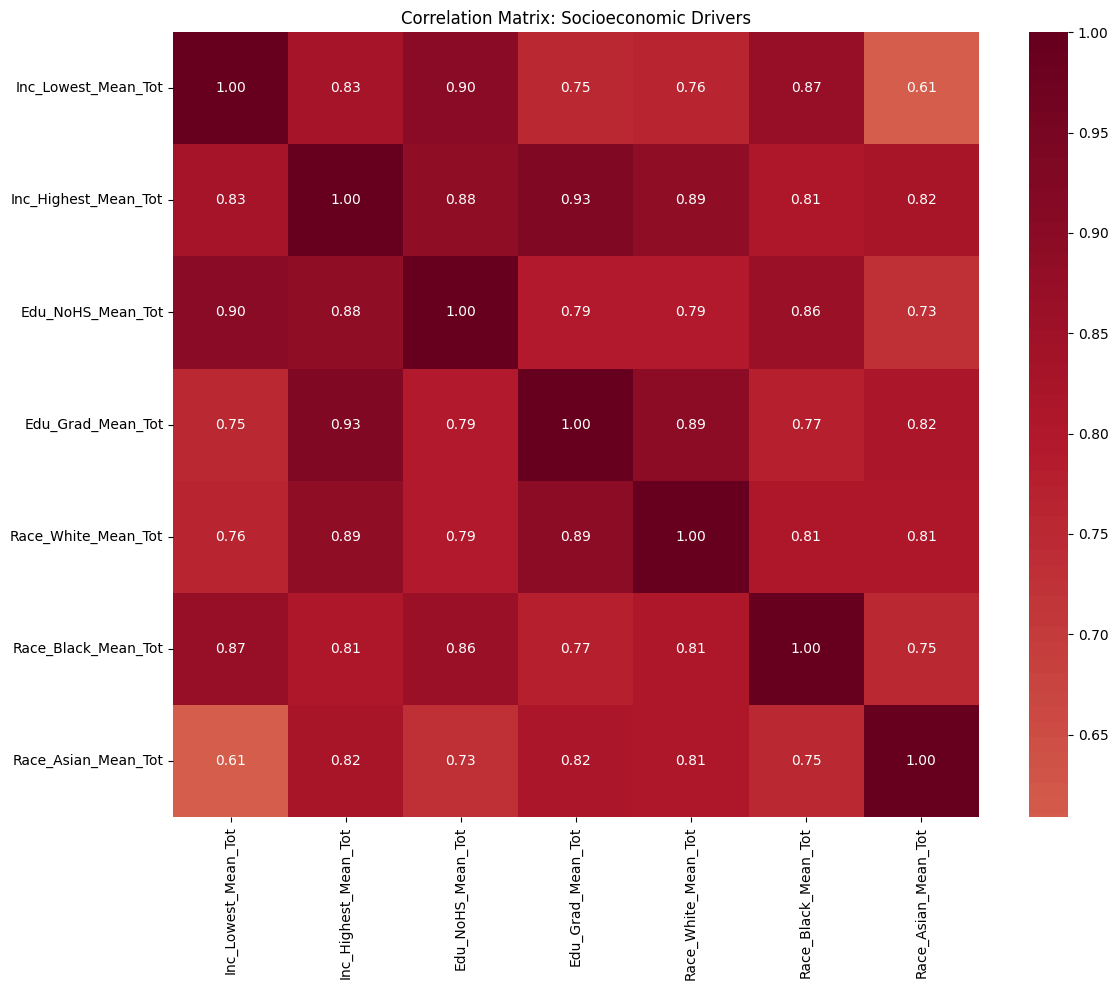

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Define features for collinearity check
# We focus on the Mean Total Scores of the demographic groups
analysis_cols = [
    'Inc_Lowest_Mean_Tot', 'Inc_Highest_Mean_Tot', 
    'Edu_NoHS_Mean_Tot', 'Edu_Grad_Mean_Tot',
    'Race_White_Mean_Tot', 'Race_Black_Mean_Tot', 'Race_Asian_Mean_Tot'
]

# 2. Clean and prepare data
# Replace 0 with np.nan (numeric null) and drop them
df_clean = df[analysis_cols].replace(0, np.nan).dropna()

# FORCE numeric type to prevent the TypeError
df_clean = df_clean.astype(float)

# 3. Add a constant column for the VIF calculation
# This is mathematically required for accurate R-squared calculation inside VIF
X = add_constant(df_clean)

# 4. Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Correlation Matrix: Socioeconomic Drivers")
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
print("Heatmap saved as 'correlation_heatmap.png'")

# 5. VIF Calculation
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Filter out the 'const' row for final reporting
vif_report = vif_data[vif_data["Feature"] != 'const'].sort_values(by="VIF", ascending=False)

print("\n--- Variance Inflation Factor (VIF) Results ---")
print("Threshold: VIF > 5-10 indicates high multicollinearity.")
print(vif_report)

The results above provide a very clear "roadmap" for our Capstone modeling strategy. 

A VIF of **14.6** for `Inc_Highest_Mean_Tot` confirms that high family income is our most collinear variable—meaning it overlaps significantly with graduate-level parental education and racial demographics. 
In contrast, `Race_Asian_Mean_Tot` at **5.0** is the most "independent" of the drivers we tested.

### **The Best Path Forward for Multiple Models for our Capstone Project**

Since our goal is to build multiple models and compare them, here is how we should handle these specific VIF results:

#### **Model 1: The "Pure Drivers" Model (Random Forest)**
* **Strategy:** Let's keep all variables. 
* **Why:** Random Forest is non-parametric and handles multicollinearity better than linear models. It will naturally "split" the importance between Income and Education. 
* **Expected Result:** We are likely to see `Inc_Highest` and `Edu_Grad` at the top of the feature importance list, but their individual importance scores might be lower than expected because they are sharing the "signal."

#### **Model 2: The "Structural Inequality" Model (Ridge/Lasso Regression)**
* **Strategy:** We will use Regularized Regression.
* **Why:** Ridge regression (L2 regularization) is specifically designed for VIF issues like ours. It shrinks the coefficients of correlated predictors, preventing the model from becoming unstable or giving nonsensical weights to `Inc_Highest`.
* **Expected Result:** A more stable prediction of `Mean_Total_Score` across different states.